# EDA기반 모델링 노트북입니다.

churn_prediction_model_ensemble_4를 기반으로 EDA에서 전처리한 feature를 사용했습니다

In [31]:
import sys
import subprocess
import importlib.util
if importlib.util.find_spec("shap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    log_loss,
)
import warnings
warnings.filterwarnings('ignore')
available_fonts = {font.name for font in fm.fontManager.ttflist}
if 'Malgun Gothic' in available_fonts:
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif 'AppleGothic' in available_fonts:
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False



## 전처리가 완료된 데이터를 불러오기

In [5]:
df = pd.read_csv("/Users/sj.kang/Desktop/project2/SKN30-2nd-1Team/notebooks/01_data_collection/EDA/preprocessed_data/preprocessed.csv")

print("타깃 분포:")
print(df['is_churned'].value_counts())
print(f"이탈 비율: {df['is_churned'].mean():.2%}")
print(f"다수 클래스 기준 baseline accuracy: {(1 - df['is_churned'].mean()):.2%}")



타깃 분포:
is_churned
0    2637
1     694
Name: count, dtype: int64
이탈 비율: 20.83%
다수 클래스 기준 baseline accuracy: 79.17%


### channel_identifier로 DB에서 channel_id와 title을 가져오기

In [10]:
#.env 로드
from dotenv import load_dotenv
load_dotenv("../../.env", override=True)

import db_utils
from importlib import reload
reload(db_utils)

#커넥션 확인
db_utils.test_connection()


DB 연결 성공
host     : 127.0.0.1:3306
database : youtube_model_db


In [11]:
load_dotenv("../../.env", override=True)

query = """
    SELECT channel_identifier, youtube_channel_id as channel_id, channel_name    
    FROM channel_info_table cit
"""
channel_df = db_utils.run_query(query, display=True)

print(f"불러온 데이터 개수: {len(channel_df)}")


,channel_identifier,channel_id,channel_name
0,CH03270,UC0kp1x32b-Y4cvP5r3vW_hw,Sereno Official
1,CH03271,UCf9JzXaRZtVThK-SAjOwC3A,Mesmi
2,CH03272,UCJQDi71H00IXCQbxAtFem3Q,DC튜브
3,CH03273,UCDYdwDXhbVZXkdV6kZn-0IQ,심킹 (ABYSSKIMG)
4,CH03274,UCTNKRL7LP51R--aQpkCq3Hg,이스 베이스볼
...,...,...,...
6541,CH11105,UCEf_Bc-KVd7onSeifS3py9g,SMTOWN
6542,CH11106,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS
6543,CH11107,UCLkAepWjdylmXSltofFvsYQ,BANGTANTV
6544,CH11108,UCOmHUn--16B90oW2L6FRR3A,BLACKPINK


불러온 데이터 개수: 6546


In [12]:
df.head()

,channel_identifier,subscriber_count,total_views,video_count,channel_age_days,collected_video_count,avg_upload_interval_days,std_upload_interval_days,max_gap_days,hiatus_count_30d,...,genre_국내+여행+해외,genre_라이프+취미,genre_레시피+요리+음식,genre_만화+애니+영화,genre_미용+패션,genre_반려동물+애완,genre_스포츠+운동,genre_어린이+키즈,genre_자동차,is_churned
0,CH03270,100000,45370000,77,3849,50,60.90,203.50,1393.0,9,...,0,0,0,0,0,0,0,0,0,0
1,CH03271,100000,8860000,448,4408,50,32.90,58.38,321.0,14,...,0,1,0,0,0,0,0,0,0,0
2,CH03272,100000,30210000,2040,3801,50,14.12,17.66,72.0,10,...,0,0,0,0,0,0,0,0,0,0
3,CH03273,100000,9650000,112,5128,50,22.61,71.67,360.0,5,...,0,0,0,1,0,0,0,0,0,1
4,CH03274,100000,195810000,252,5066,50,2.82,4.96,26.0,0,...,0,0,0,0,0,0,1,0,0,0


In [13]:
df = pd.merge(df, channel_df, on="channel_identifier", how="left")

df.head()

,channel_identifier,subscriber_count,total_views,video_count,channel_age_days,collected_video_count,avg_upload_interval_days,std_upload_interval_days,max_gap_days,hiatus_count_30d,...,genre_레시피+요리+음식,genre_만화+애니+영화,genre_미용+패션,genre_반려동물+애완,genre_스포츠+운동,genre_어린이+키즈,genre_자동차,is_churned,channel_id,channel_name
0,CH03270,100000,45370000,77,3849,50,60.90,203.50,1393.0,9,...,0,0,0,0,0,0,0,0,UC0kp1x32b-Y4cvP5r3vW_hw,Sereno Official
1,CH03271,100000,8860000,448,4408,50,32.90,58.38,321.0,14,...,0,0,0,0,0,0,0,0,UCf9JzXaRZtVThK-SAjOwC3A,Mesmi
2,CH03272,100000,30210000,2040,3801,50,14.12,17.66,72.0,10,...,0,0,0,0,0,0,0,0,UCJQDi71H00IXCQbxAtFem3Q,DC튜브
3,CH03273,100000,9650000,112,5128,50,22.61,71.67,360.0,5,...,0,1,0,0,0,0,0,1,UCDYdwDXhbVZXkdV6kZn-0IQ,심킹 (ABYSSKIMG)
4,CH03274,100000,195810000,252,5066,50,2.82,4.96,26.0,0,...,0,0,0,0,1,0,0,0,UCTNKRL7LP51R--aQpkCq3Hg,이스 베이스볼


In [14]:
df.columns

Index(['channel_identifier', 'subscriber_count', 'total_views', 'video_count',
       'channel_age_days', 'collected_video_count', 'avg_upload_interval_days',
       'std_upload_interval_days', 'max_gap_days', 'hiatus_count_30d',
       'avg_view_count', 'std_view_count', 'avg_like_count',
       'avg_comment_count', 'avg_normal_view', 'regularity_score', 'cv',
       'outlier_ratio', 'gap_ratio', 'sensitive_score', 'n_sensitive_videos',
       'sensitive_video_ratio', 'cat_politics', 'cat_hate', 'cat_aggro',
       'cat_adult_illegal', 'genre_BJ+연예인+인물', 'genre_IT+기술+컴퓨터',
       'genre_TV+방송', 'genre_가수+댄스+음악', 'genre_강의+교육', 'genre_게임',
       'genre_경제+부동산+주식', 'genre_국내+여행+해외', 'genre_라이프+취미', 'genre_레시피+요리+음식',
       'genre_만화+애니+영화', 'genre_미용+패션', 'genre_반려동물+애완', 'genre_스포츠+운동',
       'genre_어린이+키즈', 'genre_자동차', 'is_churned', 'channel_id',
       'channel_name'],
      dtype='object')

In [17]:
ALL_FEATURES = ['subscriber_count', 'total_views', 'video_count',
       'channel_age_days', 'collected_video_count', 'avg_upload_interval_days',
       'std_upload_interval_days', 'max_gap_days', 'hiatus_count_30d',
       'avg_view_count', 'std_view_count', 'avg_like_count',
       'avg_comment_count', 'avg_normal_view', 'regularity_score', 'cv',
       'outlier_ratio', 'gap_ratio', 'sensitive_score', 'n_sensitive_videos',
       'sensitive_video_ratio', 'cat_politics', 'cat_hate', 'cat_aggro',
       'cat_adult_illegal', 'genre_BJ+연예인+인물', 'genre_IT+기술+컴퓨터',
       'genre_TV+방송', 'genre_가수+댄스+음악', 'genre_강의+교육', 'genre_게임',
       'genre_경제+부동산+주식', 'genre_국내+여행+해외', 'genre_라이프+취미', 'genre_레시피+요리+음식',
       'genre_만화+애니+영화', 'genre_미용+패션', 'genre_반려동물+애완', 'genre_스포츠+운동',
       'genre_어린이+키즈', 'genre_자동차']

In [18]:
X = df[ALL_FEATURES]
y = df['is_churned']

In [19]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size= 0.2, random_state=42)

## 모델 학습

In [20]:
model_xgb = XGBClassifier(random_state=42, eval_metric="logloss")
model_lgbm = LGBMClassifier(random_state=42)
model_rf = RandomForestClassifier(random_state=42)

In [21]:
model_xgb.fit(train_X, train_y)
model_lgbm.fit(train_X, train_y)
model_rf.fit(train_X, train_y)
print("--- 모든 모델 학습 완료 ---\n")

[LightGBM] [Info] Number of positive: 552, number of negative: 2112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3859
[LightGBM] [Info] Number of data points in the train set: 2664, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207207 -> initscore=-1.341843
[LightGBM] [Info] Start training from score -1.341843
--- 모든 모델 학습 완료 ---



In [22]:
#모델별 평가를 위한 딕셔너리 세팅
models = {"XGBoost": model_xgb, "LightGBM": model_lgbm, "RandomForest": model_rf}

In [23]:
for name, model in models.items():
    # 테스트 데이터로 '이탈 여부(0 또는 1)' 예측
    preds = model.predict(test_X)

    # 테스트 데이터로 '이탈할 확률(0 ~ 1 사이)' 예측
    probs = model.predict_proba(test_X)[:, 1]

    # 평가지표 계산
    accuracy = accuracy_score(test_y, preds)
    roc_auc = roc_auc_score(test_y, probs)

    print(f"[{name} 성능 평가지표]")
    print(f" - Accuracy (정확도): {accuracy:.4f}")
    print(f" - ROC-AUC Score   : {roc_auc:.4f}")
    print("-" * 30)

[XGBoost 성능 평가지표]
 - Accuracy (정확도): 0.8201
 - ROC-AUC Score   : 0.8253
------------------------------
[LightGBM 성능 평가지표]
 - Accuracy (정확도): 0.8321
 - ROC-AUC Score   : 0.8364
------------------------------
[RandomForest 성능 평가지표]
 - Accuracy (정확도): 0.8276
 - ROC-AUC Score   : 0.8305
------------------------------


### 앙상블 기법 적용: Weighted Blending (가중 예측 확률 결합)

In [24]:
# 1. 개별 가중치 정의 (합 = 1.0)
w_lgbm = 0.5
w_xgb = 0.3
w_rf = 0.2
print(f"Ensemble Weights -> LightGBM: {w_lgbm}, XGBoost: {w_xgb}, Random Forest: {w_rf}")


Ensemble Weights -> LightGBM: 0.5, XGBoost: 0.3, Random Forest: 0.2


In [25]:
# 2. 각 모델별로 '테스트 데이터(test_X)'에 대한 이탈 확률 추출
prob_lgbm = model_lgbm.predict_proba(test_X)[:, 1]
prob_xgb = model_xgb.predict_proba(test_X)[:, 1]
prob_rf = model_rf.predict_proba(test_X)[:, 1]


In [26]:
# 3. 가중치를 곱해서 최종 앙상블 확률 계산
final_ensemble_prob = (
    (prob_lgbm * w_lgbm) + (prob_xgb * w_xgb) + (prob_rf * w_rf)
)

In [28]:
ensemble_auc = roc_auc_score(test_y, final_ensemble_prob)
print(f"가중 평균 앙상블 모델의 ROC-AUC Score: {ensemble_auc:.4f}")

가중 평균 앙상블 모델의 ROC-AUC Score: 0.8383


In [32]:
ensemble_model = VotingClassifier(
    estimators=[
        ("lgbm", model_lgbm),
        ("xgb", model_xgb),
        ("rf", model_rf),
    ],
    voting="soft",  # 확률 기반 앙상블을 위해 필수!
    weights=[0.5, 0.3, 0.2],  # 가중치 버무리기
)


In [33]:
print("--- 앙상블 통합 모델 학습 시작 ---")
ensemble_model.fit(train_X, train_y)
print("--- 학습 완료 ---\n")


--- 앙상블 통합 모델 학습 시작 ---
[LightGBM] [Info] Number of positive: 552, number of negative: 2112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3859
[LightGBM] [Info] Number of data points in the train set: 2664, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207207 -> initscore=-1.341843
[LightGBM] [Info] Start training from score -1.341843
--- 학습 완료 ---



In [34]:
final_probs = ensemble_model.predict_proba(test_X)[:, 1]


In [35]:
auc_score = roc_auc_score(test_y, final_probs)
print(f"★ 통합 앙상블 모델의 ROC-AUC Score: {auc_score:.4f}")


★ 통합 앙상블 모델의 ROC-AUC Score: 0.8383


## 채널당 이탈률 계산

In [36]:
df['churn_probability'] = ensemble_model.predict_proba(df[ALL_FEATURES])[:,1]

df

,channel_identifier,subscriber_count,total_views,video_count,channel_age_days,collected_video_count,avg_upload_interval_days,std_upload_interval_days,max_gap_days,hiatus_count_30d,...,genre_만화+애니+영화,genre_미용+패션,genre_반려동물+애완,genre_스포츠+운동,genre_어린이+키즈,genre_자동차,is_churned,channel_id,channel_name,churn_probability
0,CH03270,100000,45370000,77,3849,50,60.90,203.50,1393.0,9,...,0,0,0,0,0,0,0,UC0kp1x32b-Y4cvP5r3vW_hw,Sereno Official,0.387453
1,CH03271,100000,8860000,448,4408,50,32.90,58.38,321.0,14,...,0,0,0,0,0,0,0,UCf9JzXaRZtVThK-SAjOwC3A,Mesmi,0.133253
2,CH03272,100000,30210000,2040,3801,50,14.12,17.66,72.0,10,...,0,0,0,0,0,0,0,UCJQDi71H00IXCQbxAtFem3Q,DC튜브,0.059312
3,CH03273,100000,9650000,112,5128,50,22.61,71.67,360.0,5,...,1,0,0,0,0,0,1,UCDYdwDXhbVZXkdV6kZn-0IQ,심킹 (ABYSSKIMG),0.925073
4,CH03274,100000,195810000,252,5066,50,2.82,4.96,26.0,0,...,0,0,0,1,0,0,0,UCTNKRL7LP51R--aQpkCq3Hg,이스 베이스볼,0.019387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326,CH07237,1000000,681100000,3209,2882,50,2.00,2.78,17.0,0,...,0,0,0,0,1,0,0,UClSxH8KQdfytf2raNAByMiA,Troom Troom Kr,0.117680
3327,CH07239,1000000,639620000,2821,3953,50,0.39,0.53,2.0,0,...,0,0,0,0,0,0,1,UCAbu-rUyFqWw5k5jlSG-Jvw,V LIVE,0.771076
3328,CH07241,1000000,107020000,188,2414,50,8.49,8.70,53.0,1,...,0,1,0,0,0,0,0,UCXXlcPH1stsP3VwYG90s4wg,밀라논나 Milanonna,0.025365
3329,CH07242,1000000,983680000,2318,2873,50,0.82,1.39,5.0,0,...,0,0,0,0,0,0,0,UCJpGg1tfKID4YqvZCAig_Fw,코믹마트,0.033493


## 영향을 가장 많이 준 feature 계산

PermutationExplainer explainer: 101it [00:19,  2.55it/s]                         


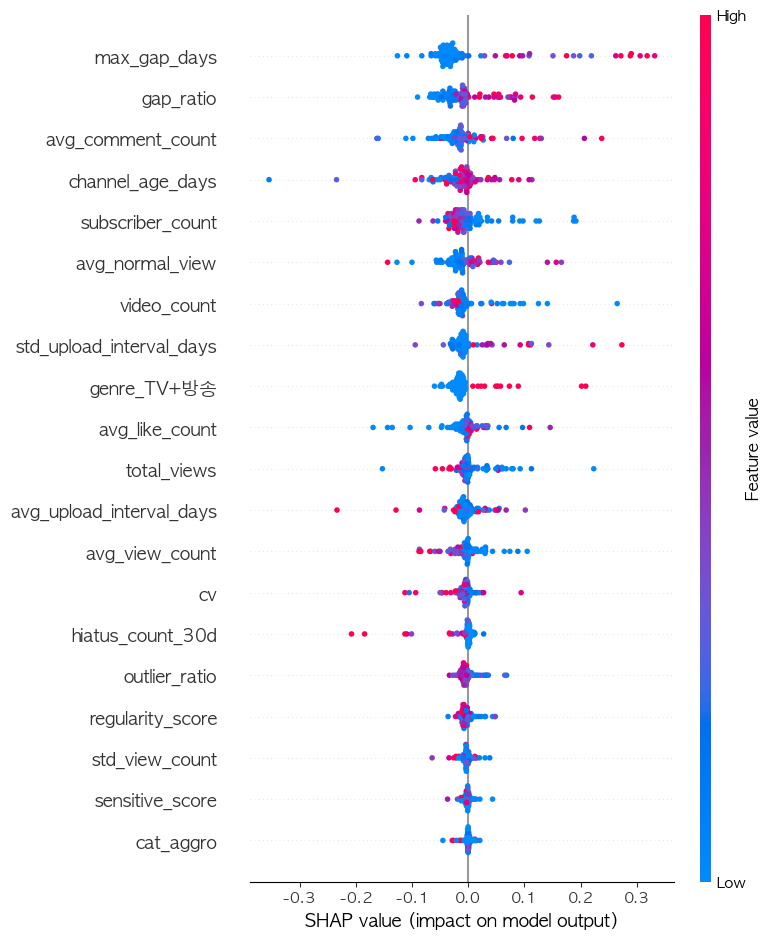

In [45]:
explainer = shap.Explainer(ensemble_model.predict, train_X)

shap_values = explainer(test_X.iloc[:100]) 

shap.summary_plot(shap_values, test_X.iloc[:100])

#

In [38]:
explainer = shap.Explainer(ensemble_model.predict_proba, train_X)
print("--- 각 채널별 SHAP 값 계산 시작 ---")
shap_results = explainer(df[ALL_FEATURES])
print("--- SHAP 값 계산 완료 ---\n")

--- 각 채널별 SHAP 값 계산 시작 ---


PermutationExplainer explainer: 3332it [10:56,  5.01it/s]                          

--- SHAP 값 계산 완료 ---



In [39]:
# 클래스 1(이탈)에 대한 SHAP 값 배열만 추출 (데이터 개수 x 피처 개수)
# explainer에 predict_proba를 넣었기 때문에 3차원 배열이 나옵니다.
shap_values_for_churn = shap_results.values[..., 1]


In [40]:
# 피처 이름 목록 가져오기
feature_names = df[ALL_FEATURES].columns.tolist()

# Top 1, Top 2, Top 3 정보를 담을 빈 리스트 생성
top1_features = []
top2_features = []
top3_features = []

In [42]:
from tqdm import tqdm

print("--- 각 채널별 이탈 유도 피처 Top 3 추출 시작 ---")
# 전체 채널(행)을 돌면서 계산
for i in tqdm(range(shap_values_for_churn.shape[0])):
    current_shap = shap_values_for_churn[i]

    # [수정된 핵심 로직] 이탈 확률을 '높인' 주범을 찾아야 하므로,
    # SHAP 값이 큰 순서대로(내림차순) 인덱스를 정렬합니다.
    # 만약 부호 상관없이 절댓값 기준으로 가장 흔들림을 많이 준 피처를 찾고 싶다면
    # np.abs(current_shap).argsort()[::-1] 을 사용하세요.
    sorted_indices = current_shap.argsort()[::-1]

    # 순서대로 Top 1, 2, 3 피처 이름 매칭
    t1_name = feature_names[sorted_indices[0]]
    t2_name = feature_names[sorted_indices[1]]
    t3_name = feature_names[sorted_indices[2]]

    top1_features.append(t1_name)
    top2_features.append(t2_name)
    top3_features.append(t3_name)

--- 각 채널별 이탈 유도 피처 Top 3 추출 시작 ---


100%|██████████| 3331/3331 [00:00<00:00, 353156.56it/s]


In [43]:
# 기존 df에 새로운 컬럼으로 추가
df["top1_churn_reason"] = top1_features
df["top2_churn_reason"] = top2_features
df["top3_churn_reason"] = top3_features
print("--- 컬럼 추가 완료! ---")

--- 컬럼 추가 완료! ---


In [44]:
df.head()

,channel_identifier,subscriber_count,total_views,video_count,channel_age_days,collected_video_count,avg_upload_interval_days,std_upload_interval_days,max_gap_days,hiatus_count_30d,...,genre_스포츠+운동,genre_어린이+키즈,genre_자동차,is_churned,channel_id,channel_name,churn_probability,top1_churn_reason,top2_churn_reason,top3_churn_reason
0,CH03270,100000,45370000,77,3849,50,60.90,203.50,1393.0,9,...,0,0,0,0,UC0kp1x32b-Y4cvP5r3vW_hw,Sereno Official,0.387453,video_count,avg_normal_view,subscriber_count
1,CH03271,100000,8860000,448,4408,50,32.90,58.38,321.0,14,...,0,0,0,0,UCf9JzXaRZtVThK-SAjOwC3A,Mesmi,0.133253,avg_view_count,subscriber_count,max_gap_days
2,CH03272,100000,30210000,2040,3801,50,14.12,17.66,72.0,10,...,0,0,0,0,UCJQDi71H00IXCQbxAtFem3Q,DC튜브,0.059312,avg_view_count,subscriber_count,avg_upload_interval_days
3,CH03273,100000,9650000,112,5128,50,22.61,71.67,360.0,5,...,0,0,0,1,UCDYdwDXhbVZXkdV6kZn-0IQ,심킹 (ABYSSKIMG),0.925073,max_gap_days,std_upload_interval_days,subscriber_count
4,CH03274,100000,195810000,252,5066,50,2.82,4.96,26.0,0,...,1,0,0,0,UCTNKRL7LP51R--aQpkCq3Hg,이스 베이스볼,0.019387,subscriber_count,cat_aggro,avg_like_count


## 예시 이탈률 계산 코드

▶ 채널명: DC튜브
▶ 예측 이탈 확률: 5.93%



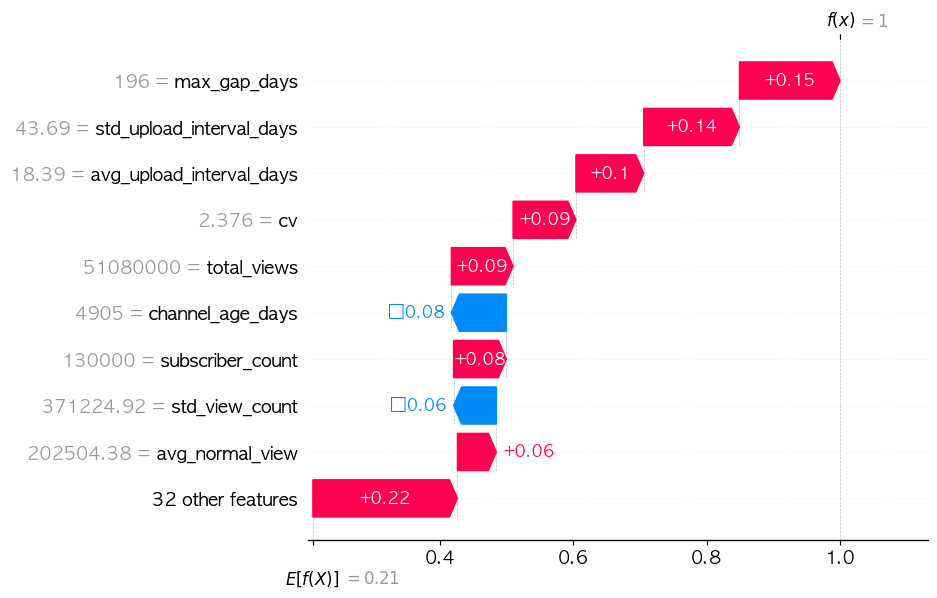

In [ ]:
target_channel_id = "UCJQDi71H00IXCQbxAtFem3Q"
single_channel_df = df[df["channel_id"] == target_channel_id]

# 2. 모델 입력에 필요한 피처들만 순서대로 추출 (1행짜리 데이터프레임)
X_single = single_channel_df[ALL_FEATURES]

# 3. 이탈 확률 계산
predicted_prob = ensemble_model.predict_proba(X_single)[0, 1]

print(f"==================================================")
print(f"▶ 채널명: {single_channel_df['channel_name'].values[0]}")
print(f"▶ 예측 이탈 확률: {predicted_prob * 100:.2f}%")
print(f"==================================================\n")

# 4. 이 채널 1개에 대한 SHAP 값 계산
shap_results_single = explainer(X_single)

# 5. [시각화] 폭포수(Waterfall) 그래프 그리기
shap.plots.waterfall(shap_values[0])